<a href="https://colab.research.google.com/github/keidenmw21-prog/MIS433/blob/main/IDMB_Visualization_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [39]:
import pandas as pd
import numpy as np

In [40]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [41]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [42]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [43]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb.Released_Year.value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [44]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
invalidyears = imdb[pd.to_numeric(imdb['Released_Year'], errors='coerce').isna()]
invalidyears

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [45]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[966,'Released_Year'] = 1995
imdb.loc[966,'Certificate'] = 'PG'

In [46]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] =imdb['Released_Year'].apply(int)

In [47]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
imdb[imdb.Released_Year >=2010][imdb.IMDB_Rating >=8.5][['Series_Title','Released_Year','Certificate','Gross']].sort_values(by='Gross',ascending=False)

/tmp/ipykernel_4108/1309032079.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  imdb[imdb.Released_Year >=2010][imdb.IMDB_Rating >=8.5][['Series_Title','Released_Year','Certificate','Gross']].sort_values(by='Gross',ascending=False)


,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [48]:
# Does the sorting result looks right to you? What's the problem?
# No, the order of the gross are not in proper order

In [49]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
imdb['Gross'] = imdb['Gross'].str.replace(',','').astype(float)

In [50]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
imdb[imdb.Released_Year >=2010][imdb.IMDB_Rating >=8.5][['Series_Title','Released_Year','Certificate','Gross']].sort_values(by='Gross',ascending=False)

/tmp/ipykernel_4108/2059615688.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  imdb[imdb.Released_Year >=2010][imdb.IMDB_Rating >=8.5][['Series_Title','Released_Year','Certificate','Gross']].sort_values(by='Gross',ascending=False)


,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [51]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min']=imdb['Runtime'].str.replace(' min','').astype(int)
imdb

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN,115
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN,201
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0,118
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN,97


In [52]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
imdb['Age_Year'] = 2026 - imdb['Released_Year']
imdb

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN,115,65
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN,201,70
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0,118,73
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN,97,82


In [53]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10
imdb

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year,Decade
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32,1990
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54,1970
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18,2000
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52,1970
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69,1950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN,115,65,1960
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN,201,70,1950
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0,118,73,1950
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN,97,82,1940


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

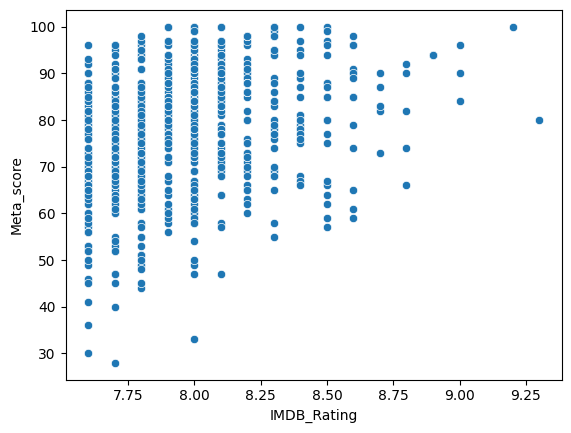

In [55]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
sns.scatterplot(data=imdb,x='IMDB_Rating',y='Meta_score')

# Based on the scatterplot, there looks to be a positive correlation between IMDB rating and meta score.

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

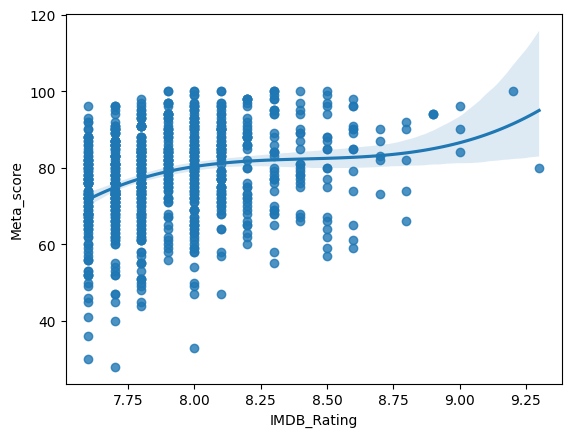

In [56]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
sns.regplot(data=imdb,x='IMDB_Rating',y='Meta_score',order=3)

In [57]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
# Some of the movies with the highest IMDB ratings have comparatively lower meta scores, like
# the Shawshank Redemption and the Dark Knight which are no.1 and no.3 on the IMDB list with
# ratings of 9.3 and 9.1 but realtively lower Meta Scores of 80.

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

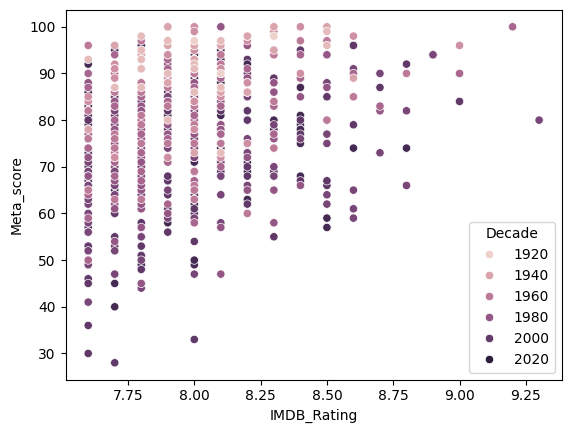

In [58]:
# In the scatterplot, use color to distinguish movies from different decades.
sns.scatterplot(data=imdb,x='IMDB_Rating',y='Meta_score',hue='Decade')

<Axes: xlabel='Decade', ylabel='Count'>

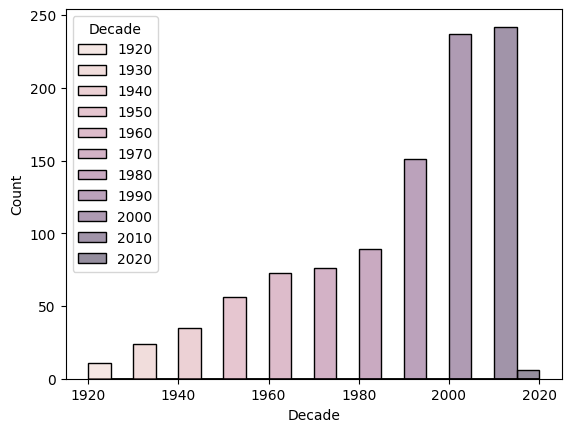

In [59]:
# Create a chart that shows how many movies fall in each decade.
sns.histplot(imdb, x="Decade",bins=20,hue='Decade')

<Axes: xlabel='Decade'>

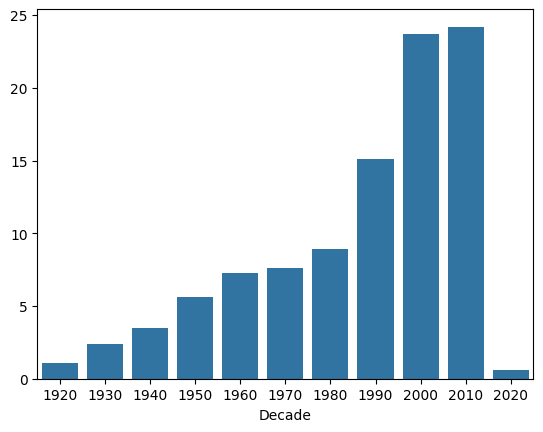

In [60]:
# Create a chart that shows the percentage of movies in each decade.
decade_percentages = imdb['Decade'].value_counts(normalize=True).mul(100).sort_index()
sns.barplot(x=decade_percentages.index, y=decade_percentages.values,)


,count
Director,
Alfred Hitchcock,14
Steven Spielberg,13
Hayao Miyazaki,11
Akira Kurosawa,10
Martin Scorsese,10
Woody Allen,9
Stanley Kubrick,9
Billy Wilder,9
Clint Eastwood,8


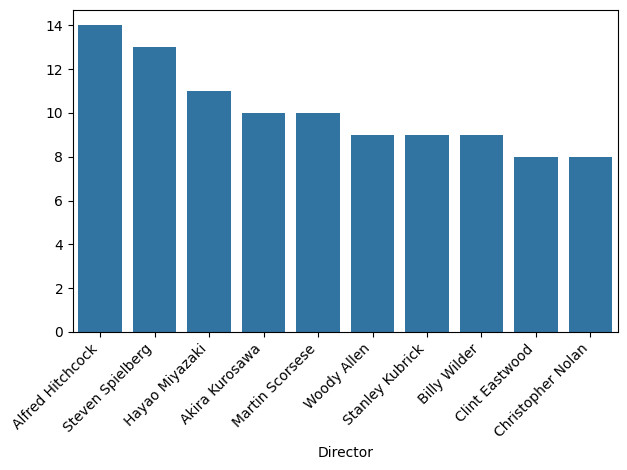

In [61]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
top_10_directors = imdb['Director'].value_counts().head(10)
display(top_10_directors)

sns.barplot(x=top_10_directors.index, y=top_10_directors.values)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


<Axes: xlabel='IMDB_Rating', ylabel='Gross'>

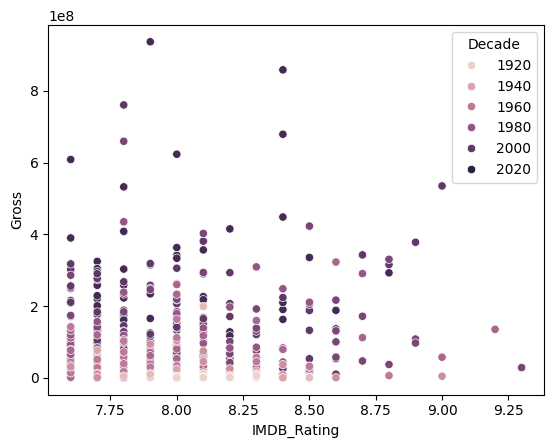

In [62]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
sns.scatterplot(data=imdb,x='IMDB_Rating',y='Gross',hue='Decade')

# The chart reveals that the highest grossing movies are all from recent decades, and that there isn't a clear association between rating and gross.

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year,Decade,Drama
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32,1990,True
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54,1970,True
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18,2000,True
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52,1970,True
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69,1950,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN,115,65,1960,True
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN,201,70,1950,True
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0,118,73,1950,True
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN,97,82,1940,True


([<matplotlib.patches.Wedge at 0x7e4d255025d0>,
 [Text(-0.7117614948343709, 0.8386868154866522, 'Drama'),
  Text(0.7117615681547013, -0.8386867532624805, 'Non-Drama')],
 [Text(-0.38823354263692955, 0.4574655357199921, '72.4%'),
  Text(0.388233582629837, -0.45746550177953477, '27.6%')])

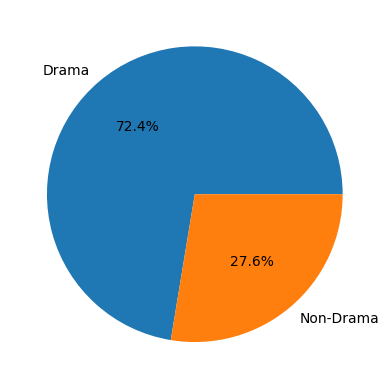

In [63]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama'] = imdb.Genre.str.contains('Drama')
display(imdb)
drama_counts = imdb['Drama'].value_counts()
plt.pie(drama_counts, labels=['Drama' if x else 'Non-Drama' for x in drama_counts.index], autopct='%1.1f%%')

<Axes: xlabel='Decade', ylabel='Gross'>

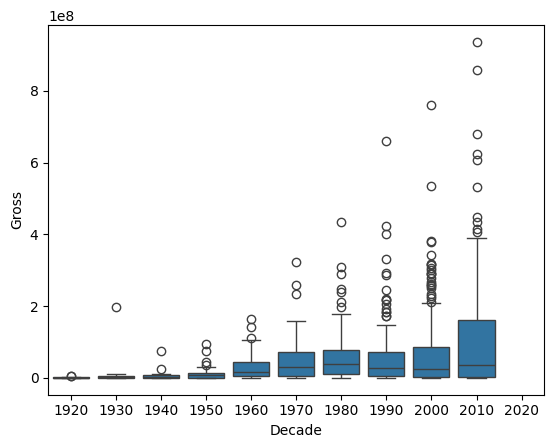

In [64]:
# Create a plot comparing gross revenue across decades.
sns.boxplot(imdb, x="Decade",y="Gross")

<Axes: xlabel='Gross', ylabel='Count'>

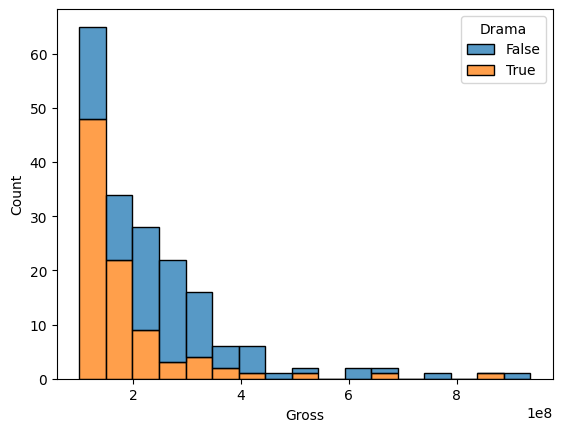

In [65]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.
movies_over_100m_gross = imdb[imdb['Gross'] > 100000000]
sns.histplot(data=movies_over_100m_gross, x='Gross', hue='Drama', multiple='stack')

<Axes: xlabel='Decade', ylabel='Runtime_min'>

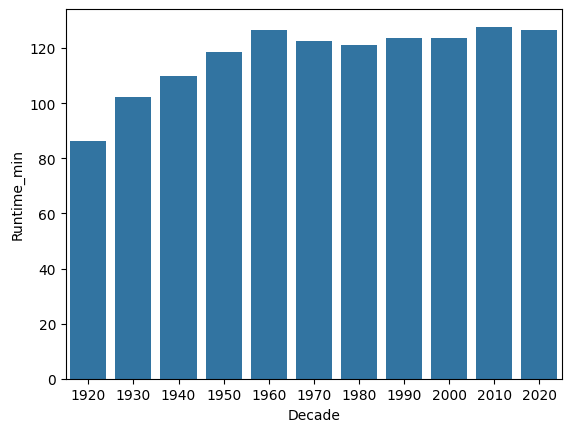

In [66]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: How has movie length changed across decades?
avg_runtime_per_decade = imdb.groupby('Decade')['Runtime_min'].mean().reset_index()
sns.barplot(x='Decade', y='Runtime_min', data=avg_runtime_per_decade)

([<matplotlib.patches.Wedge at 0x7e4d26095cd0>,
 [Text(-1.0993695100281404, -0.03723815812424899, 'U'),
  Text(-0.2034783486809815, -1.0810164483568514, 'A'),
  Text(0.9151494625138499, -0.6103289778968486, 'UA'),
  Text(1.0042740614959185, 0.4488135575119055, 'R'),
  Text(0.4024362159070319, 1.0237407348183567, 'nan'),
  Text(-0.0855393355141122, 1.0966690576832212, 'PG-13'),
  Text(-0.35885132640471257, 1.0398200447854324, 'PG'),
  Text(-0.5829112236950298, 0.932852885127319, 'Passed'),
  Text(-0.7111757895582411, 0.8391835295966029, 'G'),
  Text(-0.7699034632685534, 0.7856517404340726, 'Approved'),
  Text(-0.8037027017112731, 0.7510405896234906, 'TV-PG'),
  Text(-0.8154003884822386, 0.7383239170330422, 'GP'),
  Text(-0.822323588426543, 0.7306051710173518, 'TV-14'),
  Text(-0.8268968872445668, 0.7254250739154572, 'Unrated'),
  Text(-0.8314396159869153, 0.7202139716553206, 'TV-MA'),
  Text(-0.8359481412386398, 0.7149760171919499, '16'),
  Text(-0.8404243455010326, 0.7097090386131214, 

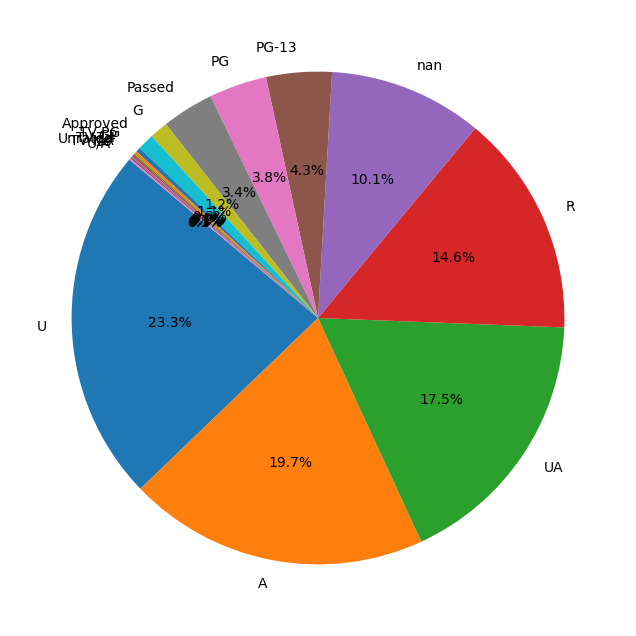

In [67]:
# Question 2: What is the distribution of certificates across all movies?
certificate_counts = imdb['Certificate'].value_counts(dropna=False)

plt.figure(figsize=(8, 8))
plt.pie(certificate_counts, labels=certificate_counts.index, autopct='%1.1f%%', startangle=140)
